In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Correct path from notebooks folder
df = pd.read_csv("../data/processed/cleaned_data.csv")

print("📊 DATA PREVIEW")
print(df.head())

print("\n📊 DATA INFO")
print(df.info())

📊 DATA PREVIEW
   Invoice Product_ID                          Description  Quantity  \
0   536365     85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1   536365      71053                  WHITE METAL LANTERN         6   
2   536365     84406B       CREAM CUPID HEARTS COAT HANGER         8   
3   536365     84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4   536365     84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          Invoice_Date  Price  Customer_ID         Country  Year  Month  Day  \
0  2010-12-01 08:26:00   2.55        17850  United Kingdom  2010     12    1   
1  2010-12-01 08:26:00   3.39        17850  United Kingdom  2010     12    1   
2  2010-12-01 08:26:00   2.75        17850  United Kingdom  2010     12    1   
3  2010-12-01 08:26:00   3.39        17850  United Kingdom  2010     12    1   
4  2010-12-01 08:26:00   3.39        17850  United Kingdom  2010     12    1   

   DayOfWeek  Total_Amount  Recency  Frequency  Monetary  Churn  Segmen

In [5]:
print("\n📊 STATISTICAL SUMMARY")
print(df.describe())

print("\n📊 UNIQUE VALUES")
print(df.nunique())

total_customers = df['Customer_ID'].nunique()
total_transactions = df['Invoice'].nunique()
avg_spending = df['Total_Amount'].mean()

print("\n📊 KEY METRICS")
print(f"Total Customers: {total_customers}")
print(f"Total Transactions: {total_transactions}")
print(f"Average Spending: {avg_spending:.2f}")


📊 STATISTICAL SUMMARY
             Invoice       Quantity          Price    Customer_ID  \
count  388805.000000  388805.000000  388805.000000  388805.000000   
mean   560600.887985       9.932614       3.143675   15287.235306   
std     13093.618376      14.597174      22.351644    1712.642475   
min    536365.000000       1.000000       0.001000   12347.000000   
25%    549235.000000       2.000000       1.250000   13956.000000   
50%    561879.000000       6.000000       1.950000   15152.000000   
75%    572069.000000      12.000000       3.750000   16791.000000   
max    581587.000000     120.000000    8142.750000   18287.000000   

                Year          Month            Day   Total_Amount  \
count  388805.000000  388805.000000  388805.000000  388805.000000   
mean     2010.934602       7.604468      15.048225      18.509145   
std         0.247227       3.415762       8.655163      73.444554   
min      2010.000000       1.000000       1.000000       0.001000   
25%      2

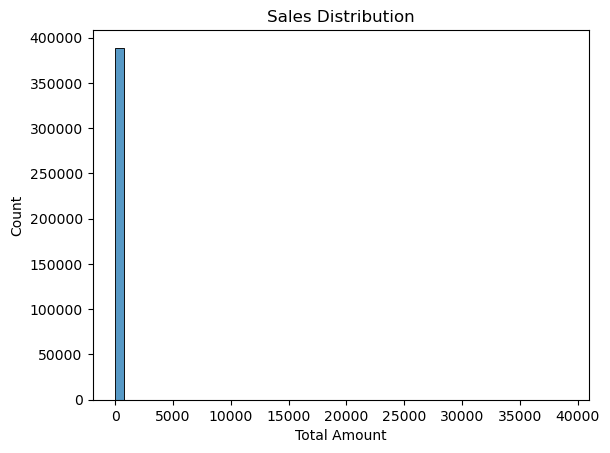


📊 INSIGHT: SALES DISTRIBUTION
• Most transactions are low value
• Few high-value transactions contribute significantly


In [25]:
sns.histplot(df['Total_Amount'], bins=50)
plt.title("Sales Distribution")
plt.xlabel("Total Amount")
plt.show()

print("\n" + "="*40)
print("📊 INSIGHT: SALES DISTRIBUTION")
print("="*40)
print("• Most transactions are low value")
print("• Few high-value transactions contribute significantly")

In [7]:
customer_count = df['Customer_ID'].nunique()
print(f"\nTotal Unique Customers: {customer_count}")

print("\nINSIGHT:")
print("• Customer base size shows business reach")


Total Unique Customers: 4303

INSIGHT:
• Customer base size shows business reach


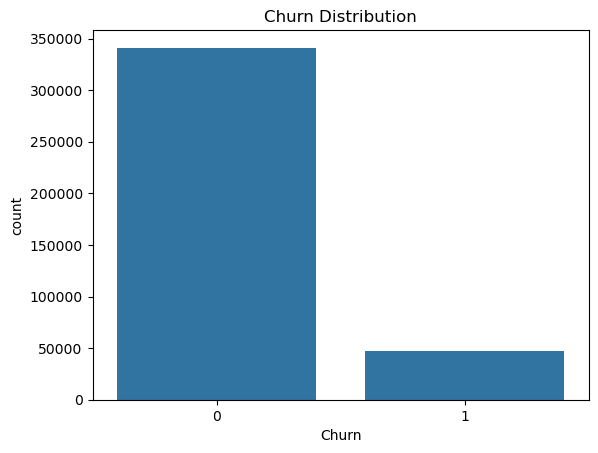


📊 INSIGHT: CHURN
• Churn Rate: 12.26%
• Majority customers are retained but churn needs attention


In [24]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

churn_rate = df['Churn'].mean() * 100

print("\n" + "="*40)
print("📊 INSIGHT: CHURN")
print("="*40)
print(f"• Churn Rate: {churn_rate:.2f}%")
print("• Majority customers are retained but churn needs attention")

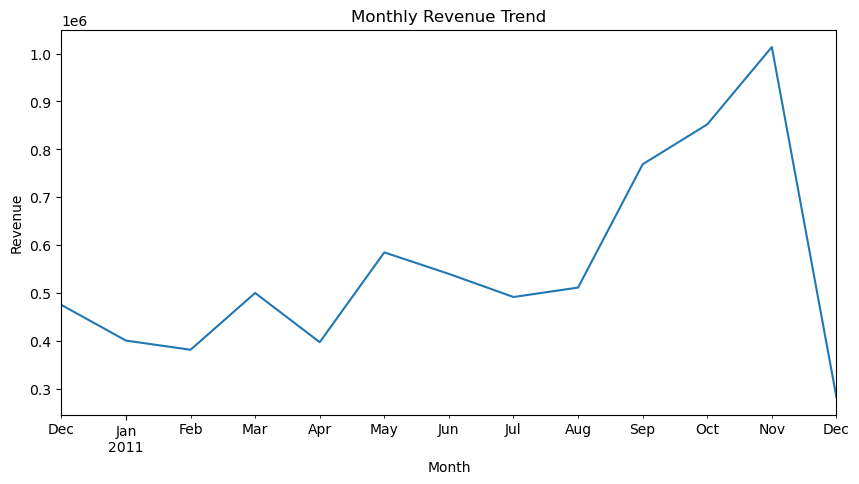


📊 INSIGHT: REVENUE TREND
• Revenue varies across months indicating seasonality
• Peak months contribute significantly to total revenue


In [21]:
df['Invoice_Date'] = pd.to_datetime(df['Invoice_Date'])

sales_trend = df.groupby(df['Invoice_Date'].dt.to_period('M'))['Total_Amount'].sum()

sales_trend.plot(figsize=(10,5))
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.savefig("../visuals/eda/monthly_revenue_trend.png")
plt.show()

print("\n" + "="*40)
print("📊 INSIGHT: REVENUE TREND")
print("="*40)
print("• Revenue varies across months indicating seasonality")
print("• Peak months contribute significantly to total revenue")

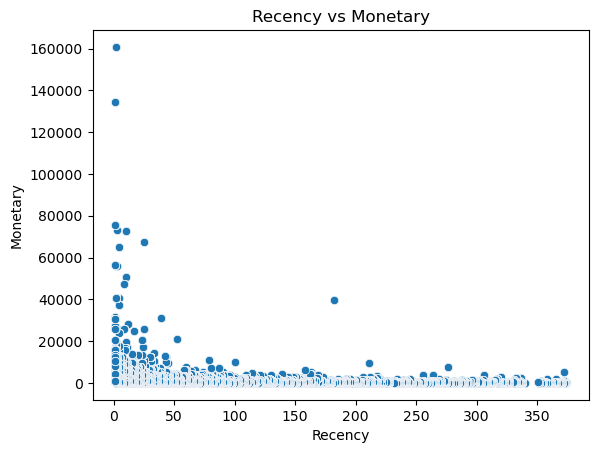


INSIGHT:
• Customers with low recency (recent buyers) spend more
• High recency customers are less active and spend less


In [10]:
sns.scatterplot(x='Recency', y='Monetary', data=df)
plt.title("Recency vs Monetary")
plt.show()

print("\nINSIGHT:")
print("• Customers with low recency (recent buyers) spend more")
print("• High recency customers are less active and spend less")

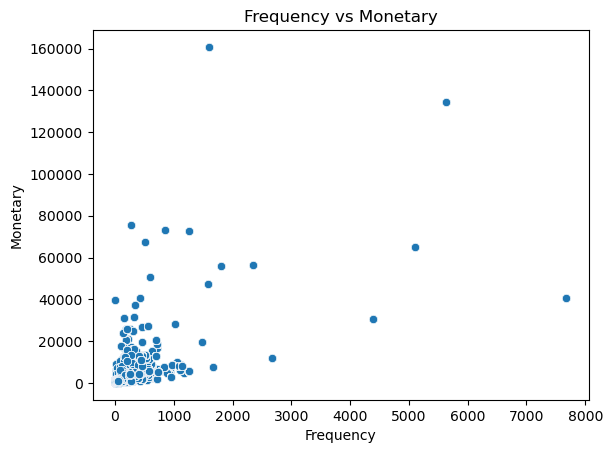


INSIGHT:
• Frequent customers generate higher revenue
• Loyal customers are key revenue drivers


In [11]:
sns.scatterplot(x='Frequency', y='Monetary', data=df)
plt.title("Frequency vs Monetary")
plt.show()

print("\nINSIGHT:")
print("• Frequent customers generate higher revenue")
print("• Loyal customers are key revenue drivers")

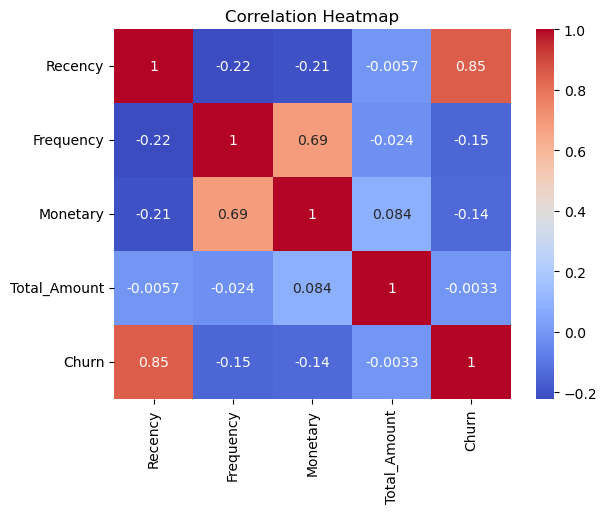


📊 INSIGHT: CORRELATION
• Recency negatively impacts spending
• Frequency positively correlates with revenue
• Churn is linked with inactive customers


In [20]:
corr = df[['Recency','Frequency','Monetary','Total_Amount','Churn']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

print("\n" + "="*40)
print("📊 INSIGHT: CORRELATION")
print("="*40)
print("• Recency negatively impacts spending")
print("• Frequency positively correlates with revenue")
print("• Churn is linked with inactive customers")

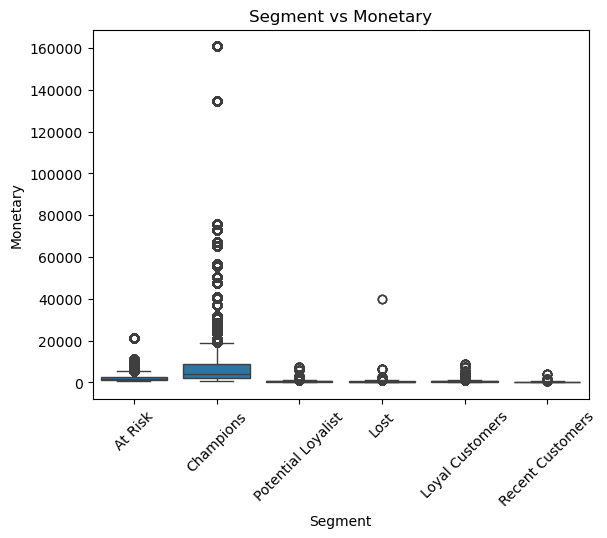


INSIGHT:
• High-value segments contribute maximum revenue
• Low-value segments require engagement strategies


In [13]:
sns.boxplot(x='Segment', y='Monetary', data=df)
plt.xticks(rotation=45)
plt.title("Segment vs Monetary")
plt.show()

print("\nINSIGHT:")
print("• High-value segments contribute maximum revenue")
print("• Low-value segments require engagement strategies")

In [14]:
total_revenue = df['Total_Amount'].sum()
total_customers = df['Customer_ID'].nunique()
churn_rate = df['Churn'].mean() * 100
avg_order_value = df['Total_Amount'].mean()

print("\n📊 BUSINESS KPI SUMMARY")
print("="*40)
print(f"Total Revenue: {total_revenue}")
print(f"Total Customers: {total_customers}")
print(f"Churn Rate: {churn_rate:.2f}%")
print(f"Average Order Value: {avg_order_value:.2f}")


📊 BUSINESS KPI SUMMARY
Total Revenue: 7196448.023999998
Total Customers: 4303
Churn Rate: 12.26%
Average Order Value: 18.51


In [15]:
print("\n" + "="*40)
print("📊 FINAL BUSINESS INSIGHTS")
print("="*40)

print("• Revenue is driven by a small group of high-value customers")
print("• Frequent buyers contribute the most to business growth")
print("• Customers with high recency are at risk of churn")
print("• Business should focus on retention and loyalty programs")


📊 FINAL BUSINESS INSIGHTS
• Revenue is driven by a small group of high-value customers
• Frequent buyers contribute the most to business growth
• Customers with high recency are at risk of churn
• Business should focus on retention and loyalty programs
